## MNIST dataset

In [1]:
from sklearn.datasets import fetch_openml

# if as_frame=True returns Pandas's dataframe, else returns Numpy arr
mnist = fetch_openml('mnist_784', as_frame=False)

print(mnist.DESCR[:500]+"...")
print(mnist.data)
print(mnist.target)

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-si...
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
['5' '0' '4' ... '4' '5' '6']


Text(0.5, 1.0, '9')

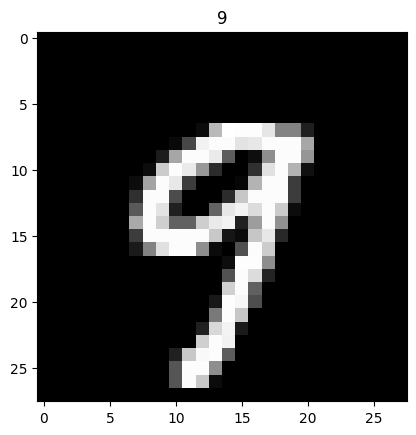

In [2]:
import matplotlib.pyplot as plt
import numpy as np

X, y = mnist.data, mnist.target
digito = X[45].reshape((28,28))
plt.imshow(digito, cmap="grey")
plt.title(y[45])

In [3]:
# Split dataset
X_train, X_test, y_train, y_test = X[:6000], X[6000:6500], y[:6000], y[6000:6500]
y_train_5, y_test_5 = (y_train == '5'), (y_test == '5')

## Confusion Matrix

In [4]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)
y_pred_5 = sgd_clf.predict(X_train)

dummy_clf = DummyClassifier() # la predicción es la clase con más miembros
dummy_clf.fit(X_train, y_train_5)
y_pred_5d = dummy_clf.predict(X_train)

In [5]:
from sklearn.metrics import confusion_matrix # [[vn, fp], [fn, vp]]
from sklearn.metrics import precision_score, recall_score, f1_score

cm_svm = confusion_matrix(y_pred_5, y_train_5)
print(cm_svm)

print("presion:", (cm_svm[1][1]/sum(cm_svm[:,1])), precision_score(y_pred_5, y_train_5)) # accuracy of the positive predictions
print("recall:", (cm_svm[1][1]/sum(cm_svm[1])), recall_score(y_pred_5, y_train_5)) # accuracy of the actual positive instances or ratio of positive instances that are correctly classified as positive
print("f1 score", (f1_score(y_train_5, y_pred_5))) # media armonica de precision y recall, entre más alto mejor

cm_dummy = confusion_matrix(y_pred_5d, y_train_5)
print(cm_dummy)

[[5447   28]
 [  39  486]]
presion: 0.9455252918287937 0.9455252918287937
recall: 0.9257142857142857 0.9257142857142857
f1 score 0.9355149181905679
[[5486  514]
 [   0    0]]


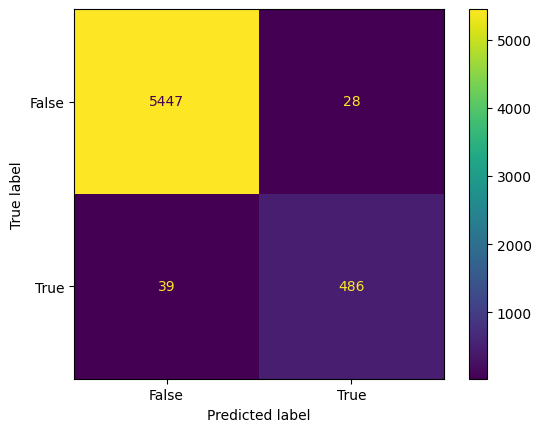

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_pred_5, y_train_5)
plt.show()

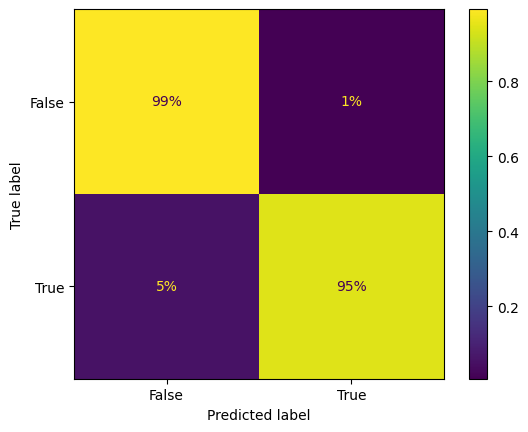

In [28]:
ConfusionMatrixDisplay.from_predictions(y_train_5, y_pred_5, normalize="true", values_format=".0%")
plt.show()

[  38042.34312442 -352270.26532035 -648999.90952906 ... -179340.05396468
 -331594.18590334 -368280.83207716]
[-1517181.24049685 -1488571.55135991 -1462856.20081505 ...
   486563.01770485   501700.4615189    505916.13752644]


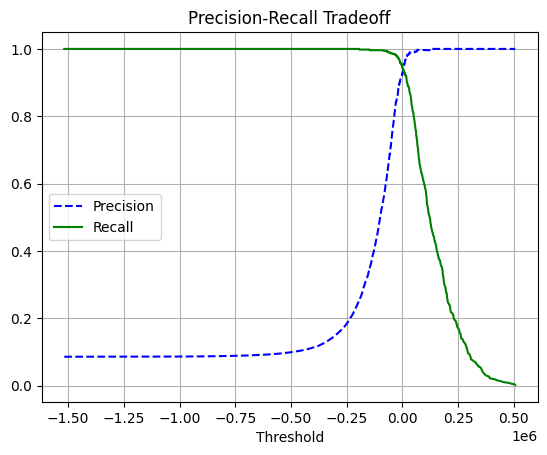

In [6]:
from sklearn.metrics import precision_recall_curve

y_scores = sgd_clf.decision_function(X_train) # returns scores, if score_instance > threshold, then instance is classified as positive else negative
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)
print(y_scores)
print(thresholds)

fig, ax = plt.subplots()

plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.grid(True)
plt.xlabel("Threshold")
plt.legend()
plt.title("Precision-Recall Tradeoff")
plt.show()

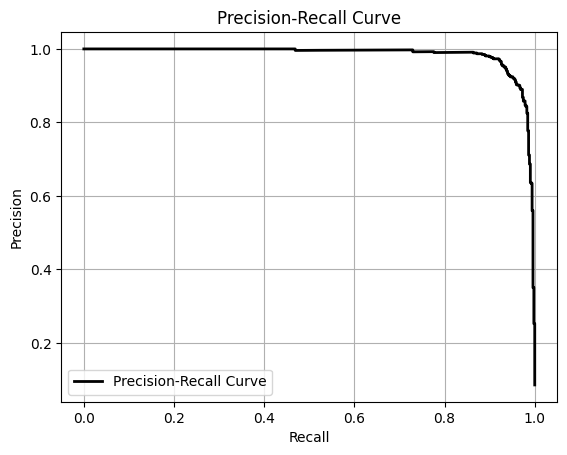

In [7]:
plt.plot(recalls, precisions, "k", linewidth=2, label="Precision-Recall Curve") # A good classifier is much closer to the top-right corner
plt.grid(True)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.title("Precision-Recall Curve")
plt.show()

0.9977853070638951


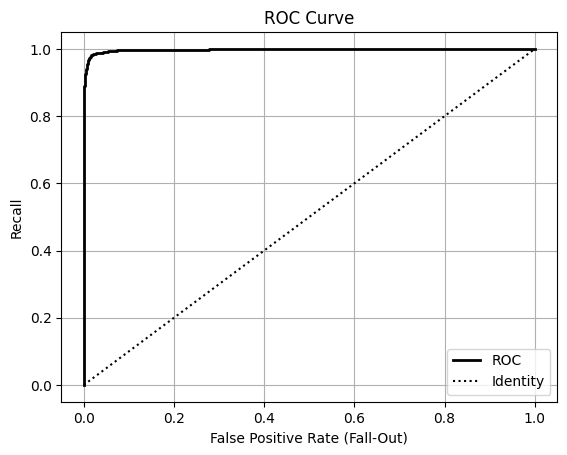

In [9]:
from sklearn.metrics import roc_curve # Receiver Operating Characteristic
from sklearn.metrics import roc_auc_score

fpr, recall, thresholds = roc_curve(y_train_5, y_scores)
print(roc_auc_score(y_train_5, y_scores)) # A good classifier stays close to 1, for a random classifier will be 0.5
fig, ax = plt.subplots()

plt.plot(fpr, recall, "k", linewidth=2, label="ROC")
plt.plot([0, 1], [0, 1], 'k:', label="Identity") # A good classifier stays as far away from this line as possible
plt.grid(True)
plt.xlabel("False Positive Rate (Fall-Out)") # ratio of negative instances that are incorrectly classified as positive
plt.ylabel("Recall")
plt.legend()
plt.title("ROC Curve")
plt.show()

## Multiclass Classifiers

In [25]:
# multinomial = multiclass
from sklearn.multiclass import OneVsRestClassifier # train a binary classifier for each class, a 0-detector, a 1-detector,...
from sklearn.multiclass import OneVsOneClassifier # train a binary classifier for every pair of digits: one for 0s and 1s, another for 0s and 2s, ...

"La mayoría de clasificadores binarios de sklearn detectan e implementan automaticamente clasificación multinomial"

ovr_clf = OneVsRestClassifier(SGDClassifier(random_state=42))
ovr_clf.fit(X_train[:5000], y_train[:5000])
print(len(ovr_clf.estimators_))

ovo_clf = OneVsOneClassifier(SGDClassifier(random_state=42))
ovo_clf.fit(X_train[:5000], y_train[:5000])
print(len(ovo_clf.estimators_)) # Nx(N-1)/2, N el número de clases

10
45


Text(0.5, 1.0, "['4']")

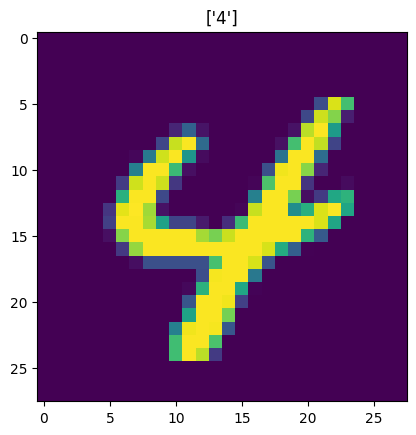

In [26]:
plt.imshow(X_test[469].reshape(28,28))
plt.title(ovr_clf.predict([X_test[469]]))

Text(0.5, 1.0, "['4']")

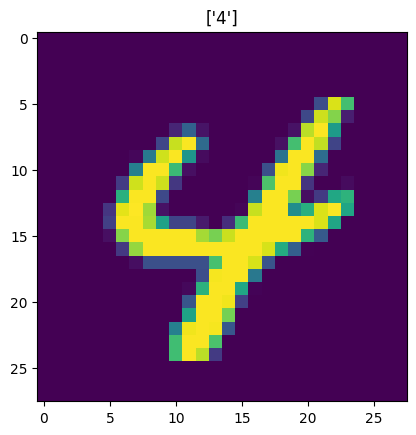

In [24]:
plt.imshow(X_test[469].reshape(28,28))
plt.title(ovo_clf.predict([X_test[469]]))

## Otras cosas

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler

from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', as_frame=False)
X, y = mnist.data, mnist.target.astype(int)


X_train, X_test, y_train, y_test = train_test_split(X[:30000], y[:30000], test_size=20)
mlp = MLPClassifier(hidden_layer_sizes=[187, 300, 187], early_stopping=True, verbose=True)

pipeline = make_pipeline(MinMaxScaler(), mlp)
pipeline.fit(X_train, y_train)

In [20]:
from sklearn.metrics import root_mean_squared_error

print(mlp.best_validation_score_)
mlp.score(X_test, y_test)

0.9793195463642428


1.0

In [5]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', as_frame=False)
X, y = mnist.data, mnist.target.astype(int)
X_train, X_test, y_train, y_test = X[:10000], X[10000:], y[:10000], y[10000:]

In [6]:
# Ej 3-1
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsOneClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler

kneigh = KNeighborsClassifier(n_neighbors=4, weights="distance")
pipeline = make_pipeline(MinMaxScaler(), kneigh)
pipeline.fit(X_train, y_train)

pipeline.score(X_test, y_test)


0.95035

In [47]:
from sklearn.metrics import accuracy_score
y_pred = pipeline.predict(X_test)
accuracy_score(y_test, y_pred) # 5: 0.9688, 6: 0.9677, 

0.9714

In [7]:
# Ej 3-2
from scipy.ndimage import shift
def shift_dir(img, dir):
    return shift(img, dir)

digito = X_train[0].reshape(28,28)
digito_l = shift_dir(digito, [0,-1])
digito_r = shift_dir(digito, [0,1])
digito_d = shift_dir(digito, [1,0])
digito_u = shift_dir(digito, [-1,0])


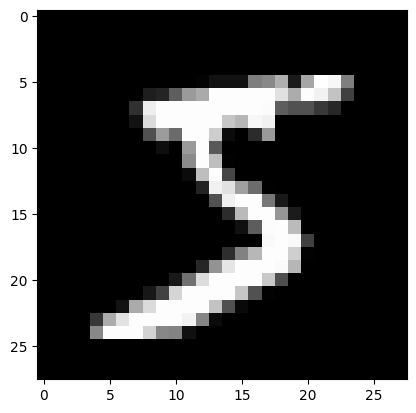

In [33]:
import matplotlib.pyplot as plt
plt.imshow(digito, cmap="grey")

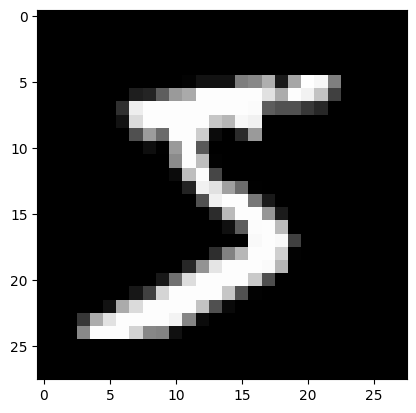

In [35]:
plt.imshow(digito_l, cmap="grey")

In [16]:
import numpy as np
X_train_exp, y_train_exp = [], []
for idx in range(X_train.shape[0]):
    X_train_exp.append(X_train[idx])
    y_train_exp.append(y_train[idx])
    dig = X_train[idx].reshape(28,28)
    X_train_exp.append(shift_dir(dig, [0,-1]).reshape(X_train[idx].shape))
    y_train_exp.append(y_train[idx])
    X_train_exp.append(shift_dir(dig, [0,1]).reshape(X_train[idx].shape))
    y_train_exp.append(y_train[idx])
    X_train_exp.append(shift_dir(dig, [-1,0]).reshape(X_train[idx].shape))
    y_train_exp.append(y_train[idx])
    X_train_exp.append(shift_dir(dig, [1,0]).reshape(X_train[idx].shape))
    y_train_exp.append(y_train[idx])

X_train_exp = np.array(X_train_exp)
y_train_exp = np.array(y_train_exp)
X_train_exp.shape

(50000, 784)

In [17]:
from sklearn.neighbors import KNeighborsClassifier

kneigh = KNeighborsClassifier(n_neighbors=4, weights="distance")
kneigh.fit(X_train_exp, y_train_exp)

kneigh.score(X_test, y_test)

0.9601666666666666